# Etap 4. projektu – Redukcja wymiarowości i wizualizacja danych

Projekt: **Automatyczne wykrywanie liczby klastrów w danych**

Celem etapu jest redukcja wymiarowości danych, analiza zachowanej informacji oraz ocena przydatności zredukowanej przestrzeni do dalszych zadań klasteryzacji.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pd.set_option("display.max_columns", 100)
sns.set_theme()


## Wczytanie danych przygotowanych w poprzednich etapach

In [2]:
DATA_PATH = "../data/processed/stage3_eda_ready.parquet"

data = pd.read_parquet(DATA_PATH)
print(data.shape)
data.head()


(30000, 13)


,LIMIT_BAL,AGE,AVG_LIMIT_UTILIZATION,PAY_MEAN,PAY_MAX,PAY_TREND,PAY_TO_BILL_RATIO,SEX_2,EDUCATION_2,EDUCATION_3,EDUCATION_4,MARRIAGE_2,MARRIAGE_3
0,-1.136720,-1.246020,-0.877698,-0.153635,1.160679,3.196120,-0.016683,0.810161,1.0669,-0.442752,-0.125886,-1.066471,-0.112812
1,-0.365981,-1.029047,-0.992741,0.694835,1.160679,-2.809044,-0.016522,0.810161,1.0669,-0.442752,-0.125886,0.937672,-0.112812
2,-0.597202,-0.161156,-0.525178,0.185753,-0.326164,-0.235402,-0.016668,0.810161,1.0669,-0.442752,-0.125886,0.937672,-0.112812
3,-0.905498,0.164303,1.131240,0.185753,-0.326164,-0.235402,-0.016726,0.810161,1.0669,-0.442752,-0.125886,-1.066471,-0.112812
4,-0.905498,2.334029,-0.024396,-0.153635,-0.326164,-1.093283,-0.016325,-1.234323,1.0669,-0.442752,-0.125886,-1.066471,-0.112812


## Przygotowanie danych do redukcji wymiarowości

Dla metod PCA i t‑SNE stosujemy standaryzację. Usuwamy ewentualne identyfikatory oraz zmienne docelowe, jeżeli występują.


In [3]:
exclude_columns = [
    "ID",
    "default.payment.next.month"
]

features = [c for c in data.columns if c not in exclude_columns]

X = data[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Liczba cech:", X.shape[1])
print("Liczba obserwacji:", X.shape[0])


Liczba cech: 13
Liczba obserwacji: 30000


## PCA – Principal Component Analysis

In [4]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

variance_df = pd.DataFrame({
    "Komponent": np.arange(1, len(explained_variance)+1),
    "ExplainedVariance": explained_variance,
    "CumulativeVariance": cumulative_variance
})

variance_df.head()


,Komponent,ExplainedVariance,CumulativeVariance
0,1,0.190273,0.190273
1,2,0.129181,0.319454
2,3,0.100163,0.419617
3,4,0.081304,0.500921
4,5,0.079247,0.580168


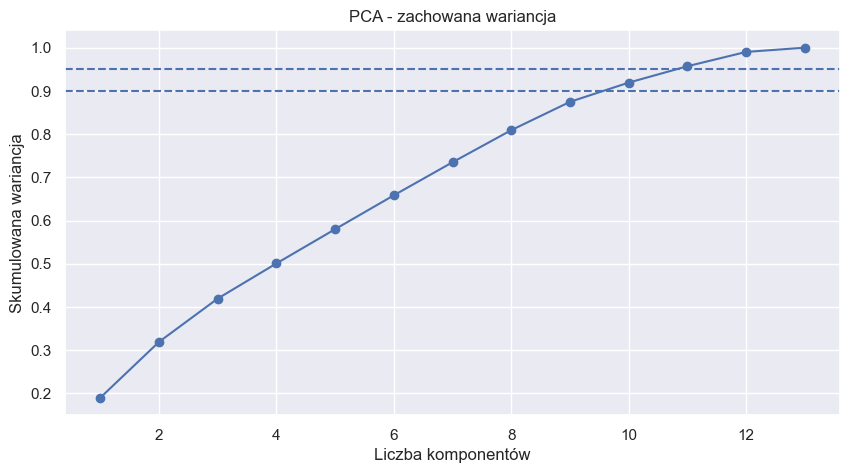

In [5]:
plt.figure(figsize=(10,5))
plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)
plt.axhline(0.90, linestyle="--")
plt.axhline(0.95, linestyle="--")
plt.xlabel("Liczba komponentów")
plt.ylabel("Skumulowana wariancja")
plt.title("PCA - zachowana wariancja")
plt.show()


In [6]:
components_90 = np.argmax(cumulative_variance >= 0.90) + 1
components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Komponenty dla 90% wariancji:", components_90)
print("Komponenty dla 95% wariancji:", components_95)


Komponenty dla 90% wariancji: 10
Komponenty dla 95% wariancji: 11


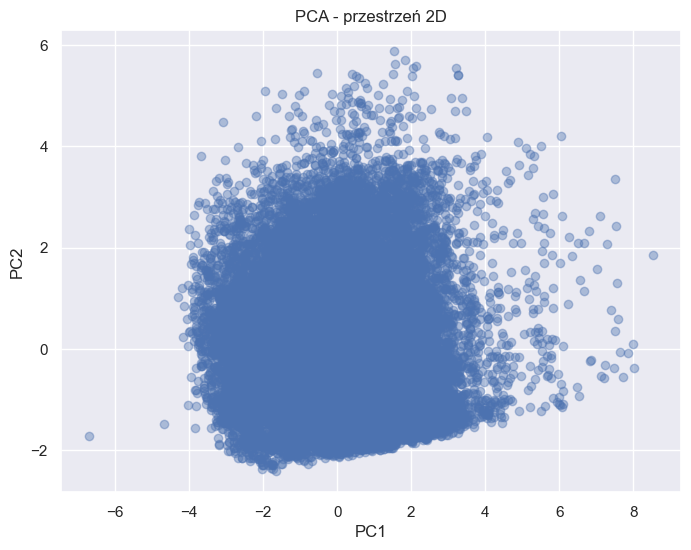

In [7]:
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"]
)

plt.figure(figsize=(8,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.4)
plt.title("PCA - przestrzeń 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


### Ocena przydatności PCA dla klasteryzacji

Porównujemy jakość klasteryzacji K-Means w przestrzeni oryginalnej i po redukcji PCA.


In [8]:
k = 4

km_original = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_original = km_original.fit_predict(X_scaled)

sil_original = silhouette_score(X_scaled, labels_original)

km_pca = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_pca = km_pca.fit_predict(X_pca_2d)

sil_pca = silhouette_score(X_pca_2d, labels_pca)

print("Silhouette (oryginalne dane):", round(sil_original, 4))
print("Silhouette (PCA 2D):", round(sil_pca, 4))


Silhouette (oryginalne dane): 0.1737
Silhouette (PCA 2D): 0.3554


## t-SNE

In [9]:
sample_size = min(5000, len(X_scaled))

indices = np.random.RandomState(42).choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_sample = X_scaled[indices]


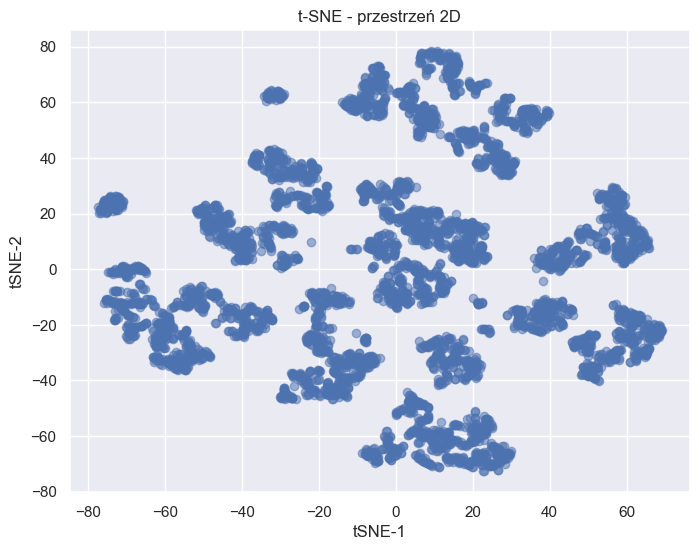

In [10]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    alpha=0.5
)
plt.title("t-SNE - przestrzeń 2D")
plt.xlabel("tSNE-1")
plt.ylabel("tSNE-2")
plt.show()


## Porównanie metod redukcji wymiarowości

Pytania do interpretacji:

1. Czy PCA ujawnia strukturę danych?
2. Czy w przestrzeni t-SNE widoczne są naturalne grupy klientów?
3. Ile informacji zachowuje PCA przy 90% i 95% wariancji?
4. Czy redukcja wymiarowości poprawia jakość klasteryzacji?
5. Czy zredukowane dane powinny zostać wykorzystane w kolejnym etapie projektu?


## Wnioski

- PCA pozwala ograniczyć liczbę cech przy zachowaniu większości informacji.
- Wykres skumulowanej wariancji umożliwia wybór liczby komponentów.
- t-SNE służy głównie do wizualizacji i oceny struktury klastrów.
- Wyniki należy porównać z metodami wyznaczania liczby klastrów analizowanymi w projekcie (Elbow, Silhouette, Gap Statistic).
- Jeżeli jakość klasteryzacji nie pogarsza się znacząco po redukcji wymiarowości, można wykorzystać dane po PCA w kolejnych etapach.
